# 02 Fuentes Climaticas

Este notebook construye el dataset de variables climaticas exogenas para el análisis de dengue en el departamento del Magdalena. El proceso tiene cinco fases:

- Carga del mapa municipal del Magdalena y calculo de centroides como coordenadas de consulta.
- Descarga de series diarias desde NASA POWER, ERA5 y CHIRPS para los 30 municipios.
- Carga de las estaciones IDEAM disponibles como referencia de observaciones terrestres.
- Validacion point-to-pixel: comparacion de las tres fuentes contra el IDEAM para seleccionar la mejor fuente por variable.
- Construcción del dataset consolidado por municipio y semana epidemiologica.

# Variables seleccionadas

Las cinco variables seleccionadas son:

| Variable | NASA POWER | ERA5 | CHIRPS | IDEAM | Estaciones |
|---|---|---|---|---|---|
| Temperatura media | T2M | temperature_2m_mean | - | Temperatura seca media diaria | 11 |
| Temperatura maxima | T2M_MAX | temperature_2m_max | - | Temperatura maxima diaria | 11 |
| Temperatura minima | T2M_MIN | temperature_2m_min | - | Temperatura minima diaria | 11 |
| Precipitacion | PRECTOTCORR | precipitation_sum | chirps | Dia pluviometrico | 68 |
| Humedad relativa | RH2M | relative_humidity_2m_mean | - | Humedad relativa media diaria | 8 |

CHIRPS solo cubre precipitación porque es un producto especializado en esa variable. NASA POWER y ERA5 cubren todas las variables.


## Temperatura (media, maxima, minima)

La temperatura es el predictor climatico con mayor respaldo en la literatura sobre 
dengue. Li et al. (2020) reportaron un incremento del 13% en el riesgo de infección 
por cada aumento de 1 grado Celsius (RR=1.13; IC95%: 1.11-1.16) en un metaanálisis 
de 106 estudios con más de cuatro millones de casos, con efecto más pronunciado en 
clima tropical monzonico (RR=1.29). La temperatura actua acortando el periodo de 
incubación extrinseco del virus DENV en el mosquito y acelerando el ciclo de vida de 
Aedes aegypti. En el contexto colombiano, Zhao et al. (2020) aplicaron modelos de 
Random Forest sobre datos SIVIGILA e identificaron la temperatura como la variable de 
mayor importancia relativa en la predicción de casos. Sebastianelli et al. (2024) 
incluyeron temperatura media y maxima como variables exogenas en su modelo ensemble 
para Brasil. Se incluyen las tres variables de temperatura para capturar tanto el 
nivel termico promedio como la amplitud diaria, que determina la supervivencia 
nocturna del vector.

## Precipitación

Zhao et al. (2020) incluyen precipitación acumulada entre las variables exogenas en su 
modelo para Colombia. Hasan et al. (2024) y Karasinghe et al. (2024) incorporan 
precipitación semanal en sus modelos ARIMA. Rahman et al. (2025) obtuvieron 
precipitación desde NASA POWER para su modelo LightGBM en Bangladesh.

## Humedad relativa

Costa et al. (2010) demostraron experimentalmente que a 25 grados Celsius y 80% de 
humedad relativa las hembras de Aedes aegypti sobreviven el doble y producen 40% mas 
huevos que a 60% de humedad. Rahman et al. (2025) incluyeron humedad relativa obtenida 
desde NASA POWER entre las variables de su modelo LightGBM.

## Fuentes de datos climaticos: reanálisis y productos satelitales

Ante la cobertura limitada e intermitente de la red de estaciones terrestres del IDEAM 
en el departamento del Magdalena, se recurre a productos de cobertura espacial completa. 
Un reanálisis combina un modelo numerico de predicción del clima con la totalidad de 
observaciones disponibles (estaciones, satelites, radiosondas) mediante asimilación de 
datos, produciendo una estimación global y continua de las variables atmosfericas. Se 
evaluan dos reanálisis y un producto satelital de precipitación:

ERA5 es el reanálisis de quinta generación del Centro Europeo de Previsión Meteorológica 
a Plazo Medio (ECMWF), distribuido a traves del servicio Copernicus. Se produce mediante 
asimilacion 4D-Var con el sistema Integrated Forecast System (IFS), asimilando 
observaciones de satelites y estaciones in-situ a una resolucion espacial nativa de 
aproximadamente 31 km y resolución horaria desde 1940.

NASA POWER es un producto derivado del reanálisis MERRA-2, producido por la Oficina de 
Modelado y Asimilacion Global (GMAO) de la NASA mediante el modelo Goddard Earth 
Observing System (GEOS) MERRA-2 asimila observaciones hiperespectrales 
de radiancia y de microondas desde 1980. NASA POWER ofrece acceso mediante API REST sin 
autenticacion, lo que facilita su descarga programatica.

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) es un producto 
satelital de precipitación de aproximadamente 5.5 km de resolucion, diseñado 
especificamente para regiones tropicales con redes de estaciones escasas. A diferencia 
de los reaáalisis, CHIRPS combina estimaciones infrarrojas de satelite con observaciones 
terrestres, lo que le otorga ventaja en la captura de eventos convectivos locales 
caracteristicos del Caribe colombiano. Urrea et al. (2016) validaron CHIRPS para 
Colombia a escala diaria, mensual y anual, confirmando su aplicabilidad en el territorio 
nacional.

## Criterio de selección de fuente por variable

La selección de la fuente principal para cada variable se basa en las metricas de 
validación point-to-pixel contra las estaciones IDEAM: RMSE, MAE y sesgo. Se adopta el 
RMSE medio entre todas las estaciones disponibles como criterio principal, por penalizar 
con mayor severidad los errores puntuales grandes, que introducen ruido sistematico en 
el dataset de modelado. La literatura respalda que la fuente optima varia segun la 
variable: ERA5 tiende a superar a NASA POWER en temperatura por su mayor resolucion 
espacial y sistema de asimilacion más reciente, mientras que ambos reanalisis subestiman 
sistematicamente la precipitación, justificando la inclusion de CHIRPS para esa variable.

# 1. Configuración

Se importan todas las librerias, se definen las constantes del proyecto y se carga el mapa municipal del Magdalena. Los centroides de cada municipio se calculan directamente del [GeoJSON del DANE](https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/) , lo que garantiza reproducibilidad y consistencia con la cartografia oficial sin necesidad de definir coordenadas manualmente.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import requests
import warnings
import ee
from epiweeks import Week

import openmeteo_requests
import requests_cache
from retry_requests import retry
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'climate'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = '2007-01-01'
END_DATE = '2024-12-31'
START_POWER = '20070101'
END_POWER = '20241231'

VARIABLES = {
    't2m_media': 'Temperatura media (C)',
    't2m_max': 'Temperatura maxima (C)',
    't2m_min': 'Temperatura minima (C)',
    'precipitacion': 'Precipitacion (mm)',
    'humedad': 'Humedad relativa (%)',
}

VARIABLES_IDEAM = {
    'temperatura_media': 't2m_media',
    'temperatura_maxima': 't2m_max',
    'temperatura_minima': 't2m_min',
    'precipitacion': 'precipitacion',
    'humedad_relativa': 'humedad'
}

DIR_IDEAM = DATA_DIR / 'external' / 'ideam'

om_session = retry(
    requests_cache.CachedSession('.cache_openmeteo', expire_after=-1),
    retries=5,
    backoff_factor=0.3
)
om_client = openmeteo_requests.Client(session=om_session) # type: ignore


def normalizar_municipio(s):
    return (
        s.str.strip().str.upper()
         .str.normalize('NFKD')
         .str.encode('ascii', errors='ignore')
         .str.decode('ascii')
    )


gdf_colombia = gpd.read_file(DATA_DIR / 'raw' / 'MGN_ADM_MPIO_GRAFICO.geojson')
magdalena = gdf_colombia[gdf_colombia['dpto_ccdgo'] == '47'].copy()
magdalena['lat'] = magdalena.geometry.centroid.y
magdalena['lon'] = magdalena.geometry.centroid.x
coords_municipios = magdalena[['mpio_cnmbr', 'lat', 'lon']].rename(
    columns={'mpio_cnmbr': 'municipio'}
).reset_index(drop=True)
coords_municipios['municipio'] = normalizar_municipio(coords_municipios['municipio'])

print(f'Proyecto: {PROJECT_ROOT}')
print(f'Municipios cargados del GeoJSON: {len(coords_municipios)}')
print(f'Variables: {list(VARIABLES.keys())}')
print(f'Periodo: {START_DATE} -> {END_DATE}')
coords_municipios.head()

Proyecto: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena
Municipios cargados del GeoJSON: 30
Variables: ['t2m_media', 't2m_max', 't2m_min', 'precipitacion', 'humedad']
Periodo: 2007-01-01 -> 2024-12-31


,municipio,lat,lon
0,SANTA MARTA,11.121894,-73.885278
1,ALGARROBO,10.253565,-74.103230
2,ARACATACA,10.644909,-73.879721
3,ARIGUANI,9.834265,-74.084601
4,CERRO DE SAN ANTONIO,10.293728,-74.819815


# 2. Descarga NASA POWER - 30 municipios

NASA POWER provee datos del reanálisis MERRA-2 procesado por la NASA con cobertura global a aproximadamente 55 km de resolución. Se consulta directamente por las coordenadas de cada municipio.

In [6]:
def get_nasa_power_diario(lat, lon, start=START_POWER, end=END_POWER):
    r = requests.get(
        'https://power.larc.nasa.gov/api/temporal/daily/point',
        params={
            'parameters': 'T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M',
            'community': 'RE',
            'longitude': lon,
            'latitude': lat,
            'start': start,
            'end': end,
            'format': 'JSON',
        },
        timeout=90,
    )
    r.raise_for_status()
    p = r.json()['properties']['parameter']
    df = pd.DataFrame({
        'fecha': pd.to_datetime(list(p['T2M'].keys()), format='%Y%m%d'),
        't2m_media': list(p['T2M'].values()),
        't2m_max': list(p['T2M_MAX'].values()),
        't2m_min': list(p['T2M_MIN'].values()),
        'precipitacion': list(p['PRECTOTCORR'].values()),
        'humedad': list(p['RH2M'].values()),
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_nasa = DATA_DIR / 'external' / 'clima_nasa_power_magdalena_diario.parquet'

if path_nasa.exists():
    df_nasa_diario = pd.read_parquet(path_nasa)
    print(f'Cargado desde cache: {df_nasa_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_nasa_power_diario(row['lat'], row['lon'])
            df['municipio'] = row['municipio']
            dfs.append(df)
            print(f'  OK {row["municipio"]}')
            time.sleep(0.4)
        except Exception as e:
            print(f'  ERROR {row["municipio"]}: {e}')
    df_nasa_diario = pd.concat(dfs, ignore_index=True)
    df_nasa_diario.to_parquet(path_nasa, index=False)
    print(f'Guardado: {path_nasa}')

df_nasa_diario['municipio'] = normalizar_municipio(df_nasa_diario['municipio'])

print(f'Shape: {df_nasa_diario.shape}')
print(f'Municipios: {df_nasa_diario["municipio"].nunique()}')
df_nasa_diario.head()

Cargado desde cache: (197250, 7)
Shape: (197250, 7)
Municipios: 30


,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2007-01-01,22.16,28.57,18.02,0.0,72.68,SANTA MARTA
1,2007-01-02,21.54,27.44,17.85,0.0,72.49,SANTA MARTA
2,2007-01-03,21.80,27.89,18.21,0.0,73.89,SANTA MARTA
3,2007-01-04,21.47,27.72,17.66,0.0,71.66,SANTA MARTA
4,2007-01-05,21.41,28.38,16.94,0.0,71.55,SANTA MARTA


# 3. Descarga ERA5 via Open-Meteo - 30 municipios

ERA5 es el reanálisis del Centro Europeo de Predicción Meteorológica (ECMWF), redistribuido por Open-Meteo con cobertura global a aproximadamente 31 km de resolución. Se consulta directamente por coordenadas.
Open-Meteo tiene un limite de aproximadamente 10 requests por minuto en el plan gratuito. Se agrega una pausa de 7 segundos entre descargas para no superar ese limite.

In [7]:
def get_era5_diario(lat, lon, start=START_DATE, end=END_DATE):
    res = om_client.weather_api(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat,
            'longitude': lon,
            'start_date': start,
            'end_date': end,
            'daily': [
                'temperature_2m_mean',
                'temperature_2m_max',
                'temperature_2m_min',
                'precipitation_sum',
                'relative_humidity_2m_mean',
            ],
            'models': 'era5',
            'timezone': 'America/Bogota',
        },
    )[0]
    daily = res.Daily()
    
    fechas = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit='s', utc=True), # type: ignore
        end=pd.to_datetime(daily.TimeEnd(), unit='s', utc=True), # type: ignore
        freq=pd.Timedelta(seconds=daily.Interval()), # type: ignore
        inclusive='left',
    ).tz_localize(None).normalize()
    df = pd.DataFrame({
        'fecha': fechas,
        't2m_media': daily.Variables(0).ValuesAsNumpy(), # type: ignore
        't2m_max': daily.Variables(1).ValuesAsNumpy(), # type: ignore
        't2m_min': daily.Variables(2).ValuesAsNumpy(), # type: ignore
        'precipitacion': daily.Variables(3).ValuesAsNumpy(), # type: ignore
        'humedad': daily.Variables(4).ValuesAsNumpy(), # type: ignore
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_era5 = DATA_DIR / 'external' / 'clima_era5_magdalena_diario.parquet'

if path_era5.exists():
    df_era5_diario = pd.read_parquet(path_era5)
    df_era5_diario['fecha'] = df_era5_diario['fecha'].dt.normalize()
    print(f'Cargado desde cache: {df_era5_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_era5_diario(row['lat'], row['lon'])
            df['municipio'] = row['municipio']
            dfs.append(df)
            print(f'OK {row["municipio"]}')
        except Exception as e:
            print(f'ERROR {row["municipio"]}: {e}')
        time.sleep(18)
    df_era5_diario = pd.concat(dfs, ignore_index=True)
    df_era5_diario.to_parquet(path_era5, index=False)
    print(f'Guardado: {path_era5}')

df_era5_diario['municipio'] = normalizar_municipio(df_era5_diario['municipio'])

print(f'Shape: {df_era5_diario.shape}')
print(f'Municipios: {df_era5_diario["municipio"].nunique()}')
df_era5_diario.head()

Cargado desde cache: (197250, 7)
Shape: (197250, 7)
Municipios: 30


,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2007-01-01,20.490999,24.566000,16.866001,4.2,82.010689,SANTA MARTA
1,2007-01-02,20.903500,26.516001,17.616001,5.6,80.337616,SANTA MARTA
2,2007-01-03,20.370169,24.866001,16.066000,10.4,82.225204,SANTA MARTA
3,2007-01-04,20.707668,24.716002,17.566000,1.7,80.244476,SANTA MARTA
4,2007-01-05,20.561838,24.116001,16.966002,0.9,81.462250,SANTA MARTA


# 4. Descarga CHIRPS via Google Earth Engine - 30 municipios

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) es un producto de precipitación con resolucion de aproximadamente 5.5 km disponible desde 1981. Combina imagenes infrarrojas de satelite con observaciones de estaciones terrestres y esta diseñado especificamente para zonas tropicales con red de estaciones escasa como el Magdalena.

Se accede via Google Earth Engine usando el dataset UCSB-CHG/CHIRPS/DAILY. Para cada municipio se extrae el valor del pixel en las coordenadas del centroide. El resultado es una serie diaria de precipitacion por municipio comparable directamente con NASA POWER y ERA5.

In [8]:
try:
    ee.Initialize(project='dengue-supervillance')
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project='dengue-supervillance')

In [9]:
def get_chirps_diario_municipio(lat, lon, nombre, start=START_DATE, end=END_DATE):
    punto = ee.Geometry.Point([lon, lat])

    def extraer_valor(imagen):
        valor = imagen.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=punto,
            scale=5000
        )
        return ee.Feature(None, {
            'fecha': imagen.date().format('YYYY-MM-dd'),
            'precipitacion': valor.get('precipitation')
        })

    filas = []
    for anio_ini in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        chunk_start = max(pd.Timestamp(f'{anio_ini}-01-01'), pd.Timestamp(start))
        chunk_end = min(pd.Timestamp(f'{anio_ini}-12-31') + pd.Timedelta(days=1), pd.Timestamp(end) + pd.Timedelta(days=1))
        chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate(
            chunk_start.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d')
        )
        datos = chirps.map(extraer_valor).getInfo()['features']
        for f in datos:
            props = f['properties']
            filas.append({
                'fecha': pd.to_datetime(props['fecha']),
                'precipitacion': props.get('precipitacion'),
                'municipio': nombre
            })
    return pd.DataFrame(filas)


path_chirps = DATA_DIR / 'external' / 'clima_chirps_magdalena_diario.parquet'

if path_chirps.exists():
    df_chirps_diario = pd.read_parquet(path_chirps)
    print(f'Cargado desde cache: {df_chirps_diario.shape}')
else:
    dfs = []
    for _, row in coords_municipios.iterrows():
        try:
            df = get_chirps_diario_municipio(row['lat'], row['lon'], row['municipio'])
            dfs.append(df)
            print(f'  OK {row["municipio"]}')
        except Exception as e:
            print(f'  ERROR {row["municipio"]}: {e}')
    df_chirps_diario = pd.concat(dfs, ignore_index=True)
    df_chirps_diario.to_parquet(path_chirps, index=False)
    print(f'Guardado: {path_chirps}')

df_chirps_diario['municipio'] = normalizar_municipio(df_chirps_diario['municipio'])

print(f'Shape: {df_chirps_diario.shape}')
print(f'Municipios: {df_chirps_diario["municipio"].nunique()}')
df_chirps_diario.head()

Cargado desde cache: (197250, 3)
Shape: (197250, 3)
Municipios: 30


,fecha,precipitacion,municipio
0,2007-01-01,6.88064,SANTA MARTA
1,2007-01-02,0.00000,SANTA MARTA
2,2007-01-03,0.00000,SANTA MARTA
3,2007-01-04,0.00000,SANTA MARTA
4,2007-01-05,0.00000,SANTA MARTA


# 5. Carga IDEAM - estaciones reales

Se cargan los parquets consolidados del IDEAM y se agregan las coordenadas reales desde los archivos _estaciones.json. Las estaciones IDEAM son las observaciones terrestres de referencia para la validacion point-to-pixel.

In [10]:
def cargar_parquet_ideam(nombre_var):
    path = DIR_IDEAM / 'consolidado' / f'{nombre_var}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'No existe {path}. Ejecuta loader_ideam.py primero.')
    df = pd.read_parquet(path)
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    return df


def agregar_coordenadas(df, variable):
    path = DIR_IDEAM / 'raw' / variable / '_estaciones.json'
    est = pd.read_json(path, dtype={'id_estacion': str})[['id_estacion', 'lat', 'lon']]
    return df.merge(est, on='id_estacion', how='left')


ideam_raw = {}
print('Estaciones IDEAM disponibles:')
for nombre_var, col_estandar in VARIABLES_IDEAM.items():
    try:
        df = cargar_parquet_ideam(nombre_var)
        df = agregar_coordenadas(df, nombre_var)
        df = df.rename(columns={'valor': col_estandar})
        df = df.dropna(subset=['lat', 'lon', col_estandar, 'fecha'])
        ideam_raw[nombre_var] = df
        n_est = df['id_estacion'].nunique()
        print(f'  {nombre_var:22} {n_est:3d} estaciones | {len(df):,} registros')
    except FileNotFoundError:
        print(f'  {nombre_var:22} NO DISPONIBLE')

ideam_raw

Estaciones IDEAM disponibles:
  temperatura_media       11 estaciones | 40,572 registros
  temperatura_maxima      11 estaciones | 36,931 registros
  temperatura_minima      11 estaciones | 38,347 registros
  precipitacion           68 estaciones | 198,047 registros
  humedad_relativa         8 estaciones | 22,872 registros


{'temperatura_media':       id_estacion                   nombre_estacion     variable  \
 0        25025090  AEROPUERTO LAS FLORES [25025090]  TEMPERATURA   
 1        25025090  AEROPUERTO LAS FLORES [25025090]  TEMPERATURA   
 2        25025090  AEROPUERTO LAS FLORES [25025090]  TEMPERATURA   
 3        25025090  AEROPUERTO LAS FLORES [25025090]  TEMPERATURA   
 4        25025090  AEROPUERTO LAS FLORES [25025090]  TEMPERATURA   
 ...           ...                               ...          ...   
 40567    15015020                  YE LA [15015020]  TEMPERATURA   
 40568    15015020                  YE LA [15015020]  TEMPERATURA   
 40569    15015020                  YE LA [15015020]  TEMPERATURA   
 40570    15015020                  YE LA [15015020]  TEMPERATURA   
 40571    15015020                  YE LA [15015020]  TEMPERATURA   
 
                            parametro      fecha unidad  t2m_media  \
 0      Temperatura seca media diaria 2007-01-01   degC  29.050000   
 1      T

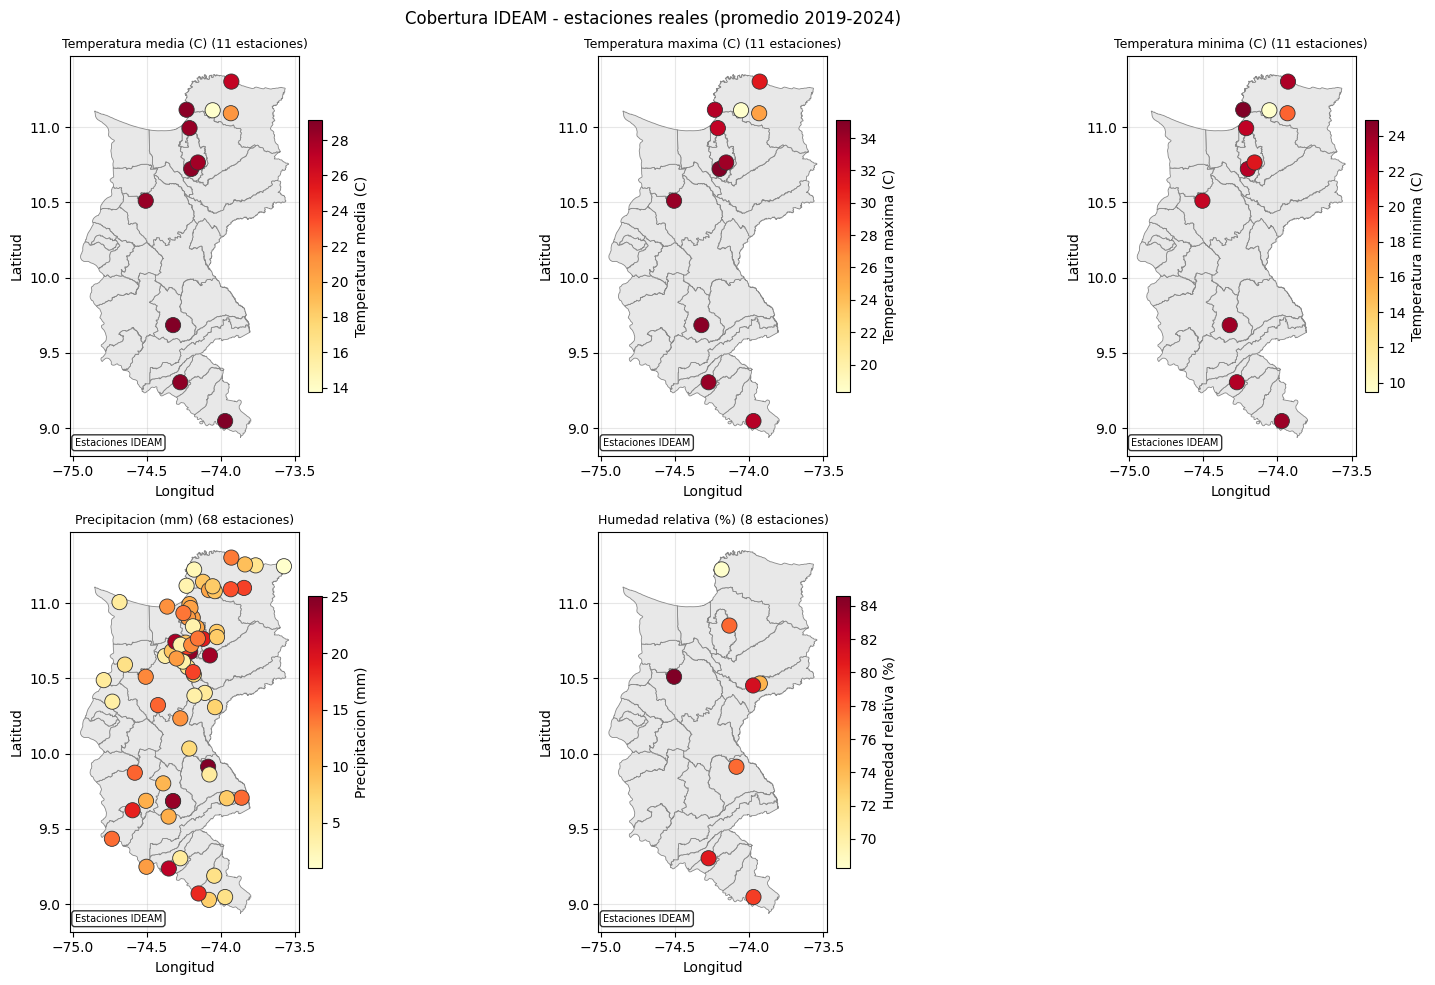

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cobertura IDEAM - estaciones reales (promedio 2019-2024)', fontsize=12)

for idx, ax in enumerate(axes.flat):
    if idx >= len(VARIABLES_IDEAM):
        ax.set_visible(False)
        continue

    nombre_var, col_estandar = list(VARIABLES_IDEAM.items())[idx]
    magdalena.plot(ax=ax, facecolor='#e8e8e8', edgecolor='#888888', linewidth=0.6, zorder=0)

    if nombre_var not in ideam_raw:
        ax.set_title(f'{VARIABLES[col_estandar]}\n(sin datos)', fontsize=9)
        continue

    df = ideam_raw[nombre_var]
    agg = df.groupby(['id_estacion', 'lat', 'lon'])[col_estandar].mean().reset_index()

    vmin, vmax = agg[col_estandar].min(), agg[col_estandar].max()
    if vmin == vmax:
        vmax = vmin + 1
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    sc = ax.scatter(
        agg['lon'], agg['lat'],
        s=120,
        c=agg[col_estandar], cmap='YlOrRd', norm=norm,
        edgecolors='#333333', linewidths=0.6, zorder=2,
    )
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label=VARIABLES[col_estandar])
    ax.set_title(f"{VARIABLES[col_estandar]} ({agg['id_estacion'].nunique()} estaciones)",
                 fontsize=9)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.text(0.02, 0.02, 'Estaciones IDEAM',
            transform=ax.transAxes, fontsize=7,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR /'ideam_estaciones_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Validación point-to-pixel

Para evaluar la calidad de NASA POWER, ERA5 y CHIRPS respecto a observaciones reales se usa el enfoque point-to-pixel: se descarga cada fuente exactamente en las coordenadas de cada estacion IDEAM y se comparan los valores directamente contra las observaciones terrestres.

Las metricas calculadas son:

- RMSE: error cuadratico medio. Penaliza mas los errores grandes. Mismas unidades que la variable.
- MAE: error absoluto medio. Mas robusto a valores extremos que el RMSE.
- Bias: sesgo sistematico. Positivo significa que la fuente sobreestima, negativo que subestima.

CHIRPS solo se valida para precipitación porque es el unico parametro que provee.

In [12]:
filas = []
for nombre_var, df in ideam_raw.items():
    est = df[['id_estacion', 'municipio', 'lat', 'lon']].drop_duplicates('id_estacion')
    filas.append(est)
coords_estaciones = pd.concat(filas).drop_duplicates('id_estacion').reset_index(drop=True)
print(f'Total estaciones unicas: {len(coords_estaciones)}')
coords_estaciones.head(10)

Total estaciones unicas: 73


,id_estacion,municipio,lat,lon
0,25025090,El Banco,9.046333,-73.970833
1,15015050,Santa Marta,11.114694,-74.231028
2,15015110,Santa Marta,11.091500,-73.932389
3,25025300,San Sebastián De Buenavista,9.683667,-74.322278
4,25025002,San Sebastián De Buenavista,9.304056,-74.273639
5,29065000,Pivijai,10.510028,-74.506667
6,29065020,Zona Bananera,10.721111,-74.199722
7,15015100,Santa Marta,11.301674,-73.928809
8,29065030,Zona Bananera,10.764167,-74.154722
9,15015060,Santa Marta,11.111083,-74.054694


In [14]:
path_nasa_est = DATA_DIR / 'external' / 'clima_nasa_power_estaciones_ideam.parquet'
path_era5_est = DATA_DIR / 'external' / 'clima_era5_estaciones_ideam.parquet'

if path_nasa_est.exists():
    df_nasa_est = pd.read_parquet(path_nasa_est)
    print(f'NASA estaciones cargado desde cache: {df_nasa_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows(): # type: ignore
        try:
            df = get_nasa_power_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'OK {row["id_estacion"]}')
            time.sleep(0.4)
        except Exception as e:
            print(f'ERROR {row["id_estacion"]}: {e}')
    df_nasa_est = pd.concat(dfs, ignore_index=True)
    df_nasa_est.to_parquet(path_nasa_est, index=False)
    print(f'Guardado: {path_nasa_est}')

if path_era5_est.exists():
    df_era5_est = pd.read_parquet(path_era5_est)
    df_era5_est['fecha'] = df_era5_est['fecha'].dt.normalize()
    print(f'ERA5 estaciones cargado desde cache: {df_era5_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows(): # type: ignore
        try:
            df = get_era5_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'OK {row["id_estacion"]}')
        except Exception as e:
            print(f'ERROR {row["id_estacion"]}: {e}')
        time.sleep(18)
    df_era5_est = pd.concat(dfs, ignore_index=True)
    df_era5_est.to_parquet(path_era5_est, index=False)
    print(f'Guardado: {path_era5_est}')

NASA estaciones cargado desde cache: (479975, 7)
OK 25025090
OK 15015050
OK 15015110
OK 25025300
OK 25025002
OK 29065000
OK 29065020
OK 15015100
OK 29065030
OK 15015060
OK 15015020
OK 25021600
OK 29060350
OK 28040150
OK 15010020
OK 29060150
OK 29060560
OK 25021610
OK 29060030
OK 28040320
OK 29060140
OK 29060060
OK 25025000
OK 29060160
OK 29060340
OK 25021500
OK 15010310
OK 29060190
OK 29060040
OK 29020020
OK 29060170
OK 15010300
OK 28040360
OK 15010501
OK 25021620
OK 29060180
OK 29060200
OK 25021190
OK 29060210
OK 1501500196
OK 29060080
OK 25021200
OK 29060250
OK 25021040
OK 15010010
OK 28040100
OK 25021630
OK 29060270
OK 15030020
OK 29060330
OK 29060550
OK 29050020
OK 28040140
OK 29060280
OK 29060070
OK 29060540
OK 25021380
OK 25020900
OK 29060100
OK 25021030
OK 29060230
OK 29060310
OK 29060120
OK 25021020
OK 29050010
OK 29060240
OK 28040300
OK 15010040
OK 25025360
OK 29065120
OK 29065140
OK 29065130
OK 15015120
Guardado: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\ext

In [15]:
path_chirps_est = DATA_DIR / 'external' / 'clima_chirps_estaciones_ideam.parquet'

if path_chirps_est.exists():
    df_chirps_est = pd.read_parquet(path_chirps_est) 
    print(f'CHIRPS estaciones cargado desde cache: {df_chirps_est.shape}')
else:
    est_precip = ideam_raw['precipitacion'][['id_estacion', 'lat', 'lon']].drop_duplicates('id_estacion')
    dfs = []
    for _, row in est_precip.iterrows(): # type: ignore
        try:
            punto = ee.Geometry.Point([row['lon'], row['lat']])

            def extraer(imagen):
                valor = imagen.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=punto,
                    scale=5000
                )
                return ee.Feature(None, {
                    'fecha': imagen.date().format('YYYY-MM-dd'),
                    'precipitacion': valor.get('precipitation')
                })

            filas = []
            for anio_ini in range(pd.Timestamp(START_DATE).year, pd.Timestamp(END_DATE).year + 1):
                chunk_start = max(pd.Timestamp(f'{anio_ini}-01-01'), pd.Timestamp(START_DATE))
                chunk_end = min(pd.Timestamp(f'{anio_ini}-12-31') + pd.Timedelta(days=1), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
                chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate(
                    chunk_start.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d')
                )
                datos = chirps.map(extraer).getInfo()['features']
                filas.extend([{
                    'fecha': pd.to_datetime(f['properties']['fecha']),
                    'precipitacion': f['properties'].get('precipitacion'),
                    'id_estacion': row['id_estacion']
                } for f in datos])
            df = pd.DataFrame(filas)
            dfs.append(df)
            print(f'OK {row["id_estacion"]}')
        except Exception as e:
            print(f'ERROR {row["id_estacion"]}: {e}')
    df_chirps_est = pd.concat(dfs, ignore_index=True)
    df_chirps_est.to_parquet(path_chirps_est, index=False)
    print(f'Guardado: {path_chirps_est}')

CHIRPS estaciones cargado desde cache: (447100, 3)


Se definen funciones intermedias para el calculo de metricas y agregación semanal con la convención CDC/OPS (sunday-start) consistente con el sistema de SIVIGILA

In [17]:

def fecha_a_semana_epi(fecha):
    f = pd.Timestamp(fecha)
    if pd.isna(f):
        return None, None
    w = Week.fromdate(f.date(), system="CDC")
    return w.year, w.week


def calcular_metricas(y_obs, y_pred, min_n=10):
    mask = ~(np.isnan(y_obs) | np.isnan(y_pred))
    if mask.sum() < min_n:
        return {'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan, 'N': int(mask.sum())}
    yo = y_obs[mask]
    yp = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yo, yp))
    mae = mean_absolute_error(yo, yp)
    bias = float(np.mean(yp - yo))
    return {
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'Bias': round(bias, 3),
        'N': int(mask.sum())
    }

def _agregar_semana_epi_serie(serie_fecha, valores, col_v):
    df_tmp = pd.DataFrame({'fecha': pd.to_datetime(serie_fecha), col_v: valores})
    semanas = df_tmp['fecha'].apply(lambda f: fecha_a_semana_epi(f))
    df_tmp['anio_epi'] = semanas.apply(lambda x: x[0])
    df_tmp['semana_epi'] = semanas.apply(lambda x: x[1])
    agg = df_tmp.groupby(['anio_epi', 'semana_epi'])[col_v]
    return agg.mean()
    

def validar_par(ideam_s, fuente_s, col_v, escala):
    if escala == 'diaria':
        m = ideam_s[[col_v]].join(fuente_s[[col_v]], rsuffix='_pred', how='inner')
        return calcular_metricas(m[col_v].values, m[f'{col_v}_pred'].values, min_n=10)
    else:
        obs_sem = _agregar_semana_epi_serie(ideam_s.index, ideam_s[col_v].values, col_v)
        pred_sem = _agregar_semana_epi_serie(fuente_s.index, fuente_s[col_v].values, col_v)
        m = pd.concat([obs_sem.rename('obs'), pred_sem.rename('pred')], axis=1, join='inner')
        return calcular_metricas(m['obs'].values, m['pred'].values, min_n=10)


rows = []
for nombre_var, col_v in VARIABLES_IDEAM.items():
    if nombre_var not in ideam_raw:
        continue
    df_v = ideam_raw[nombre_var][['id_estacion', 'fecha', col_v, 'lat', 'lon']]

    for id_est in df_v['id_estacion'].unique():
        ideam_s = df_v[df_v['id_estacion'] == id_est].set_index('fecha').sort_index()
        nasa_s = df_nasa_est[df_nasa_est['id_estacion'] == id_est].set_index('fecha').sort_index()
        era5_s = df_era5_est[df_era5_est['id_estacion'] == id_est].set_index('fecha').sort_index()
        lat = float(ideam_s['lat'].iloc[0])
        lon = float(ideam_s['lon'].iloc[0])

        fuentes = {'NASA POWER': nasa_s, 'ERA5': era5_s}
        if col_v == 'precipitacion':
            fuentes['CHIRPS'] = df_chirps_est[df_chirps_est['id_estacion'] == id_est].set_index('fecha').sort_index()

        for nombre_fuente, fuente_s in fuentes.items():
            for escala in ['diaria', 'semanal']:
                met = validar_par(ideam_s, fuente_s, col_v, escala)
                rows.append({
                    'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                    'fuente': nombre_fuente, 'escala': escala, **met
                })

df_metricas = pd.DataFrame(rows)
print(f'Metricas calculadas: {len(df_metricas)} filas ({df_metricas["escala"].nunique()} escalas)')
display(df_metricas)


Metricas calculadas: 572 filas (2 escalas)


,variable,id_estacion,lat,lon,fuente,escala,RMSE,MAE,Bias,N
0,t2m_media,25025090,9.046333,-73.970833,NASA POWER,diaria,1.907,1.565,-1.018,5068
1,t2m_media,25025090,9.046333,-73.970833,NASA POWER,semanal,1.698,1.429,-1.028,764
2,t2m_media,25025090,9.046333,-73.970833,ERA5,diaria,1.220,0.986,-0.580,5068
3,t2m_media,25025090,9.046333,-73.970833,ERA5,semanal,1.017,0.837,-0.573,764
4,t2m_media,15015050,11.114694,-74.231028,NASA POWER,diaria,1.734,1.556,-1.527,4673
...,...,...,...,...,...,...,...,...,...,...
567,humedad,29065000,10.510028,-74.506667,ERA5,semanal,9.907,8.338,-8.197,309
568,humedad,15015120,11.223056,-74.185917,NASA POWER,diaria,14.162,9.330,8.579,4317
569,humedad,15015120,11.223056,-74.185917,NASA POWER,semanal,14.271,9.111,8.729,674
570,humedad,15015120,11.223056,-74.185917,ERA5,diaria,16.731,12.489,12.231,4317


Las métricas por estación se agregan promediando sobre todas las estaciones
disponibles por variable, obteniendo un RMSE, MAE y sesgo representativo
del departamento para cada fuente y escala.

In [18]:
resumen = (
    df_metricas
    .groupby(['variable', 'fuente', 'escala'])
    .agg(
        RMSE_media=('RMSE', 'mean'),
        MAE_media=('MAE', 'mean'),
        Bias_medio=('Bias', 'mean'),
        N_estaciones=('id_estacion', 'count')
    )
    .round(3)
    .reset_index()
)
resumen['Variable'] = resumen['variable'].map(VARIABLES)

print('Comparacion de fuentes contra observaciones IDEAM (2019-2024):')
print('Escala diaria:')
print(
    resumen[resumen['escala'] == 'diaria']
    [['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio', 'N_estaciones']]
    .to_string(index=False)
)
print('\nEscala semanal (la usada en el modelo):')
print(
    resumen[resumen['escala'] == 'semanal']
    [['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio', 'N_estaciones']]
    .to_string(index=False)
)
resumen[['Variable', 'fuente', 'escala', 'RMSE_media', 'MAE_media', 'Bias_medio', 'N_estaciones']]


Comparacion de fuentes contra observaciones IDEAM (2019-2024):
Escala diaria:
              Variable     fuente  RMSE_media  MAE_media  Bias_medio  N_estaciones
  Humedad relativa (%)       ERA5      13.041      7.900       1.362             8
  Humedad relativa (%) NASA POWER      16.121     11.978      -6.138             8
    Precipitacion (mm)     CHIRPS      18.799     10.699      -5.355            68
    Precipitacion (mm)       ERA5      20.861     12.451      -1.073            68
    Precipitacion (mm) NASA POWER      19.418     10.599      -7.108            68
Temperatura maxima (C)       ERA5       2.564      2.243      -1.807            11
Temperatura maxima (C) NASA POWER       3.585      3.174      -0.244            11
 Temperatura media (C)       ERA5       1.143      0.921      -0.103            11
 Temperatura media (C) NASA POWER       2.208      1.957       0.412            11
Temperatura minima (C)       ERA5       2.536      2.149       1.998            11
Temperatu

,Variable,fuente,escala,RMSE_media,MAE_media,Bias_medio,N_estaciones
0,Humedad relativa (%),ERA5,diaria,13.041,7.900,1.362,8
1,Humedad relativa (%),ERA5,semanal,13.071,7.576,1.600,8
2,Humedad relativa (%),NASA POWER,diaria,16.121,11.978,-6.138,8
3,Humedad relativa (%),NASA POWER,semanal,15.736,11.567,-5.786,8
4,Precipitacion (mm),CHIRPS,diaria,18.799,10.699,-5.355,68
5,Precipitacion (mm),CHIRPS,semanal,13.373,8.552,-6.731,68
6,Precipitacion (mm),ERA5,diaria,20.861,12.451,-1.073,68
7,Precipitacion (mm),ERA5,semanal,13.847,9.209,-3.076,68
8,Precipitacion (mm),NASA POWER,diaria,19.418,10.599,-7.108,68
9,Precipitacion (mm),NASA POWER,semanal,14.709,9.597,-8.307,68


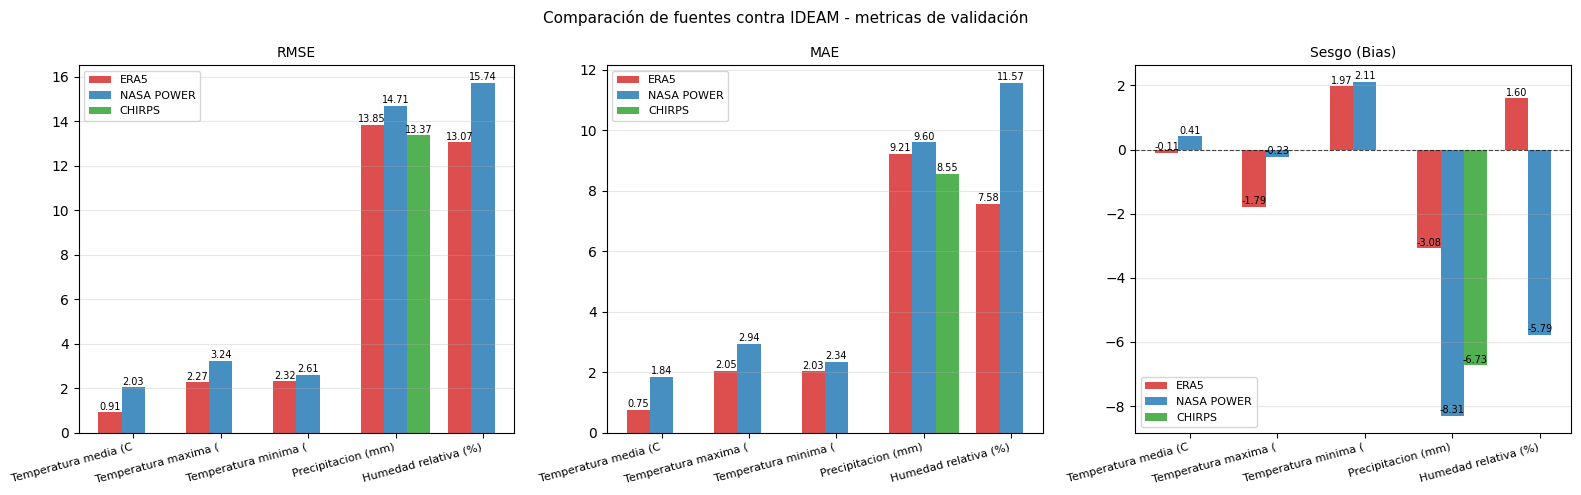

In [19]:
vars_list = list(VARIABLES.keys())
etiquetas_var = [VARIABLES[v][:20] for v in vars_list]
x = np.arange(len(vars_list))

metricas_defs = [('RMSE', 'RMSE'), ('MAE', 'MAE'), ('Bias', 'Sesgo (Bias)')]
colores_fuente = {'NASA POWER': '#1f77b4', 'ERA5': '#d62728', 'CHIRPS': '#2ca02c'}

resumen_plot = (
    df_metricas[df_metricas['escala'] == 'semanal']
    .groupby(['variable', 'fuente'])[['RMSE', 'MAE', 'Bias']]
    .mean()
    .reset_index()
)

fuentes_disponibles = resumen_plot['fuente'].unique().tolist()
n_fuentes = len(fuentes_disponibles)
width = 0.8 / n_fuentes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de fuentes contra IDEAM - metricas de validación', fontsize=11)

for idx, (met_col, met_label) in enumerate(metricas_defs):
    ax = axes[idx]
    for k, fuente in enumerate(fuentes_disponibles):
        vals = []
        for col_v in vars_list:
            row = resumen_plot[
                (resumen_plot['variable'] == col_v) & (resumen_plot['fuente'] == fuente)
            ]
            vals.append(float(row[met_col].iloc[0]) if len(row) > 0 else np.nan)
        offset = (k - (n_fuentes - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=fuente,
                      color=colores_fuente.get(fuente, '#888888'), alpha=0.82)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.02,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)

    if met_col == 'Bias':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas_var, fontsize=8, rotation=15, ha='right')
    ax.set_title(met_label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validacion_metricas_resumen.png',
            dpi=150, bbox_inches='tight')
plt.show()

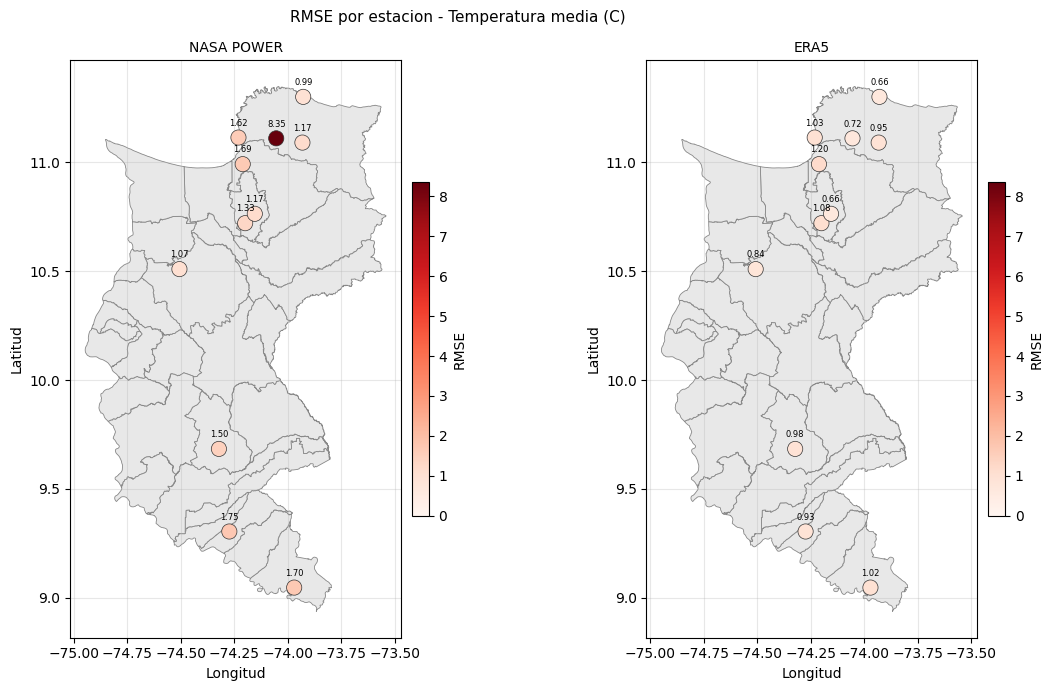

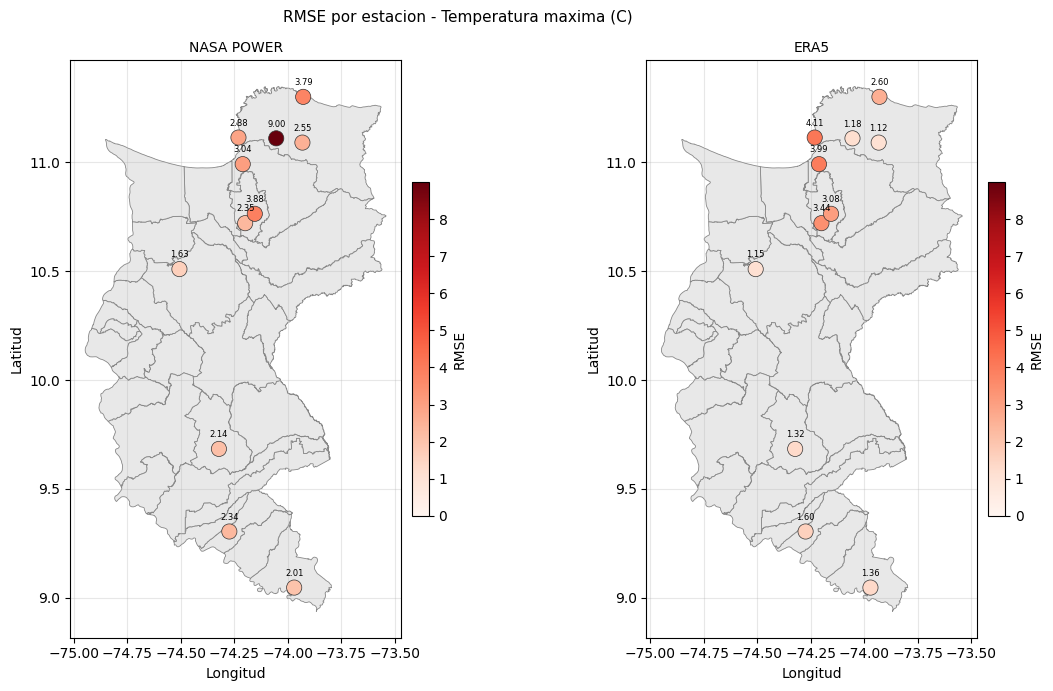

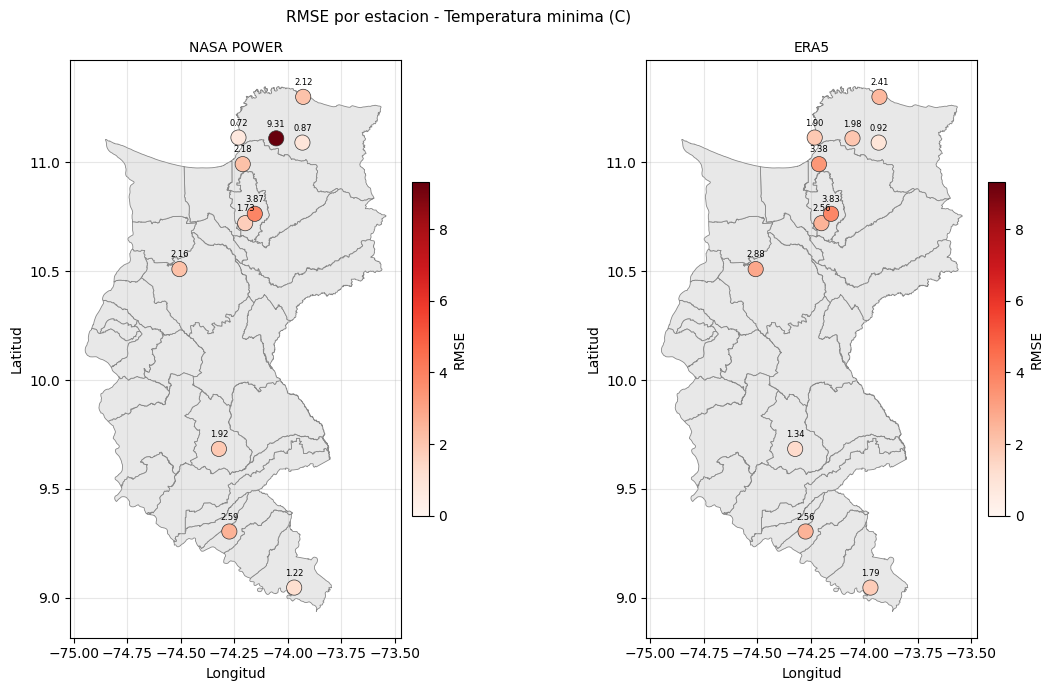

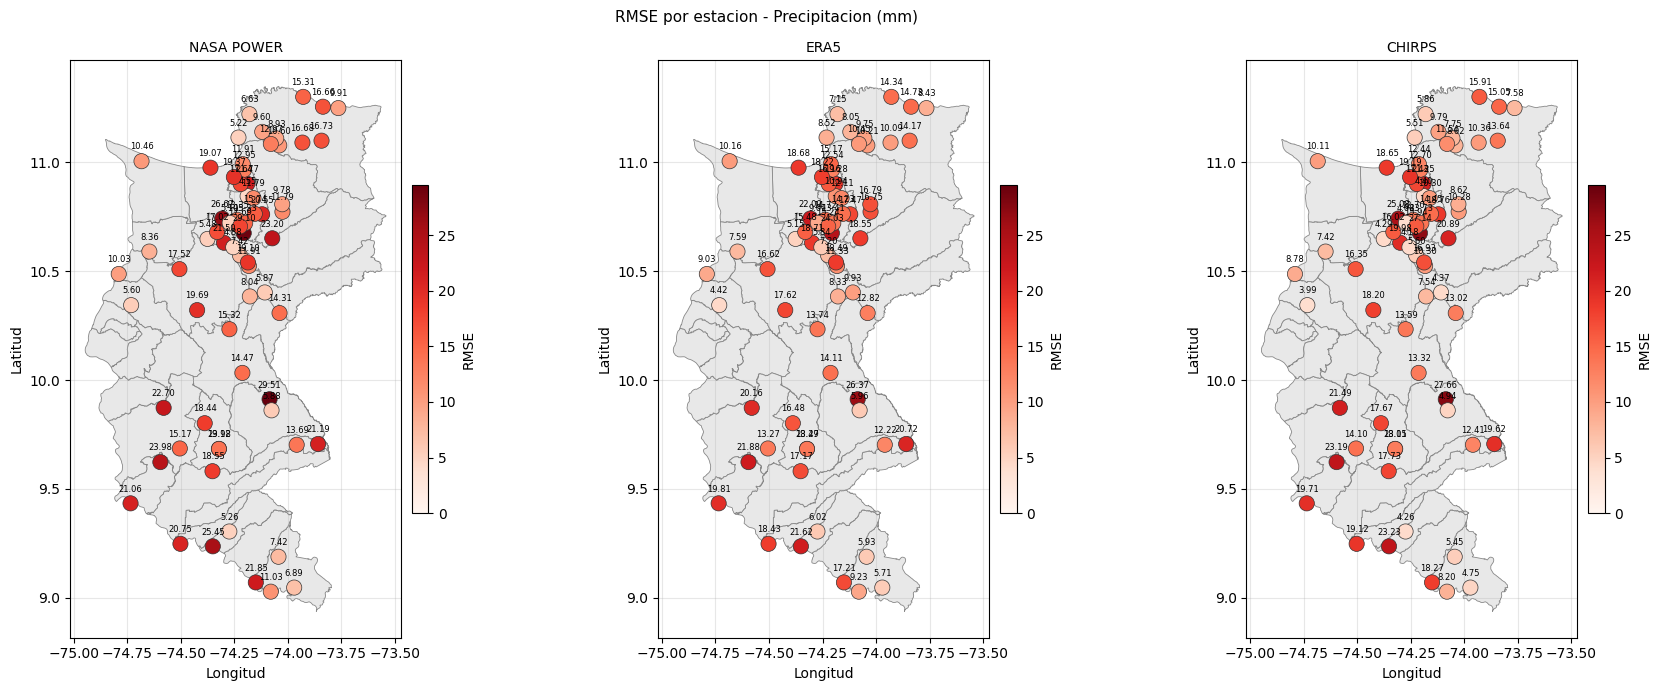

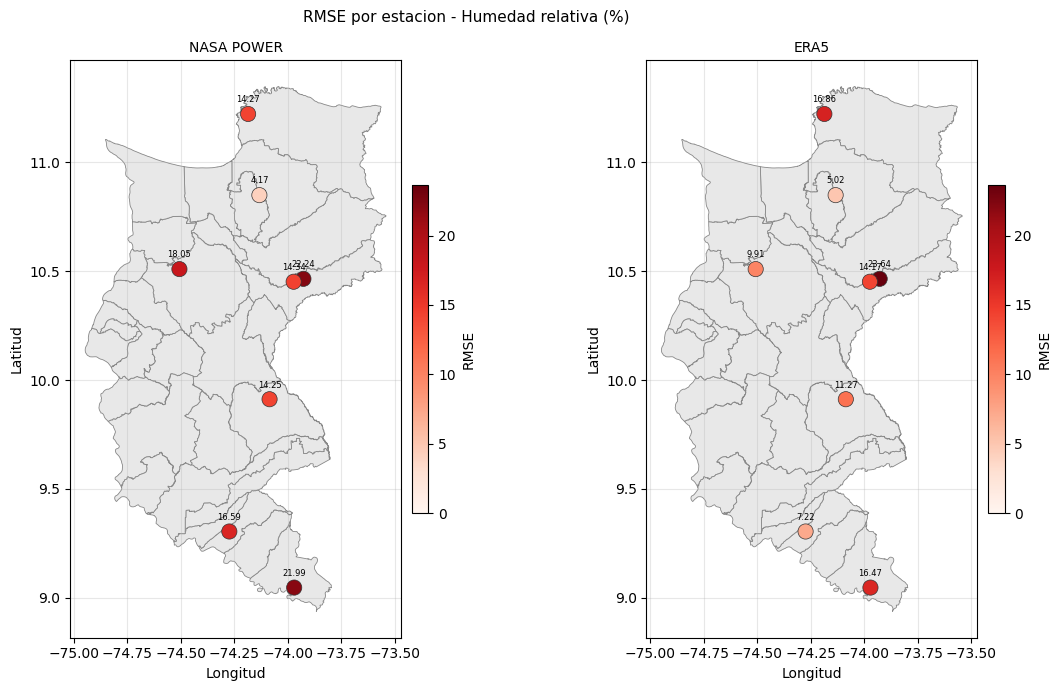

In [20]:
vars_list_mapa = list(VARIABLES_IDEAM.values())


df_metricas_mapa = df_metricas[df_metricas['escala'] == 'semanal']

for col_v in vars_list_mapa:
    fuentes_var = df_metricas_mapa[df_metricas_mapa['variable'] == col_v]['fuente'].unique()
    n_fuentes_var = len(fuentes_var)
    
    sub_var = df_metricas_mapa[df_metricas_mapa['variable'] == col_v].dropna(subset=['RMSE'])
    vmax_global = sub_var['RMSE'].max()
    norm = mcolors.Normalize(vmin=0, vmax=vmax_global if vmax_global > 0 else 1)

    fig, axes = plt.subplots(1, n_fuentes_var, figsize=(6 * n_fuentes_var, 7))
    if n_fuentes_var == 1:
        axes = [axes]
    fig.suptitle(f'RMSE por estacion - {VARIABLES[col_v]}', fontsize=11)

    for ax, fuente in zip(axes, fuentes_var):
        sub = df_metricas_mapa[
            (df_metricas_mapa['variable'] == col_v) &
            (df_metricas_mapa['fuente'] == fuente)
        ].dropna(subset=['RMSE'])

        magdalena.plot(ax=ax, facecolor='#e8e8e8', edgecolor='#888888', linewidth=0.6, zorder=0)

        if len(sub) > 0:
            sc = ax.scatter(
                sub['lon'], sub['lat'],
                s=120,
                c=sub['RMSE'], cmap='Reds', norm=norm,
                edgecolors='#333333', linewidths=0.5, zorder=2,
            )
            plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='RMSE')
            for _, row in sub.iterrows():
                ax.annotate(f"{row['RMSE']:.2f}", (row['lon'], row['lat']),
                            fontsize=6, ha='center', va='bottom',
                            xytext=(0, 7), textcoords='offset points')

        ax.set_title(fuente, fontsize=10)
        ax.set_xlabel('Longitud')
        ax.set_ylabel('Latitud')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    nombre_archivo = col_v.replace('/', '_')
    plt.savefig(OUTPUT_DIR / f'rmse_mapa_{nombre_archivo}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# 7. Selección de fuente por variable

Con base en las metricas de la sección anterior se selecciona la fuente principal para cada variable. El criterio es el menor RMSE medio entre todas las estaciones disponibles para esa variable

In [21]:
resumen_sem = resumen[resumen['escala'] == 'semanal']
seleccion = (
    resumen_sem
    .sort_values('RMSE_media')
    .groupby('variable')
    .first()
    .reset_index()[['variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio']]
)
seleccion['Variable'] = seleccion['variable'].map(VARIABLES)

print('Fuente seleccionada por variable (menor RMSE, escala semanal):')
print(seleccion[['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'Bias_medio']].to_string(index=False))


fuente_por_variable = dict(zip(seleccion['variable'], seleccion['fuente']))
print('\nDiccionario de seleccion:')
for var, fuente in fuente_por_variable.items():
    print(f'{var}: {fuente}')


Fuente seleccionada por variable (menor RMSE, escala semanal):
              Variable fuente  RMSE_media  MAE_media  Bias_medio
  Humedad relativa (%)   ERA5      13.071      7.576       1.600
    Precipitacion (mm) CHIRPS      13.373      8.552      -6.731
Temperatura maxima (C)   ERA5       2.269      2.051      -1.786
 Temperatura media (C)   ERA5       0.914      0.750      -0.107
Temperatura minima (C)   ERA5       2.321      2.027       1.968

Diccionario de seleccion:
humedad: ERA5
precipitacion: CHIRPS
t2m_max: ERA5
t2m_media: ERA5
t2m_min: ERA5


# 8. Dataset consolidado - agregación semanal

Se construye el dataset final con la fuente ganadora para cada variable, seleccionada en la seccion anterior. La agregacion a semana epidemiologica usa la convencion CDC/OPS (Sunday-start) implementada con la libreria epiweeks, consistente con el sistema SIVIGILA. Para precipitación se usa suma semanal; para temperatura y humedad se usa promedio semanal. El dataset incluye una columna fecha_semana con el primer dia (domingo) de cada semana epidemiologica, que se usara como variable temporal en el modelamiento.


In [23]:
def agregar_semanal(df, col_v):
    df = df.copy()
    semanas = df['fecha'].apply(lambda f: fecha_a_semana_epi(f))
    df['anio_epi'] = semanas.apply(lambda x: x[0]).astype(int)
    df['semana_epi'] = semanas.apply(lambda x: x[1]).astype(int)
    agg = df.groupby(['anio_epi', 'semana_epi'])[col_v]
    return (agg.mean()).reset_index()


cols_clima = list(VARIABLES.keys())

# Mapeo de fuente a DataFrame diario
df_por_fuente = {
    'NASA POWER': df_nasa_diario,
    'ERA5': df_era5_diario,
    'CHIRPS': df_chirps_diario,
}

# Construir dataset con la fuente ganadora por variable
dfs_sem = []
for col_v, fuente in fuente_por_variable.items():
    df_fuente = df_por_fuente[fuente]
    df_v = agregar_semanal(df_fuente[['fecha', col_v]], col_v)
    dfs_sem.append(df_v)
    print(f'{col_v}: fuente={fuente}')

# Merge de todas las variables
df_clima = dfs_sem[0]
for df_v in dfs_sem[1:]:
    df_clima = df_clima.merge(df_v, on=['anio_epi', 'semana_epi'], how='outer')

df_clima['fecha_semana'] = df_clima.apply(
    lambda r: pd.Timestamp(
        Week(int(r['anio_epi']), int(r['semana_epi']), system='CDC').startdate()
    ), axis=1
)

print(f'\nDataset climatico consolidado:')
print(f'Shape: {df_clima.shape}')
print(f'Semanas: {df_clima.groupby(["anio_epi","semana_epi"]).ngroups}')
print(f'Columnas: {df_clima.columns.tolist()}')

(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)
df_clima.to_parquet(DATA_DIR / 'processed' / 'clima_semanal_magdalena.parquet', index=False)
print(f'\nGuardado: data/processed/clima_semanal_magdalena.parquet')
df_clima.head()

humedad: fuente=ERA5
precipitacion: fuente=CHIRPS
t2m_max: fuente=ERA5
t2m_media: fuente=ERA5
t2m_min: fuente=ERA5

Dataset climatico consolidado:
Shape: (940, 8)
Semanas: 940
Columnas: ['anio_epi', 'semana_epi', 'humedad', 'precipitacion', 't2m_max', 't2m_media', 't2m_min', 'fecha_semana']

Guardado: data/processed/clima_semanal_magdalena.parquet


,anio_epi,semana_epi,humedad,precipitacion,t2m_max,t2m_media,t2m_min,fecha_semana
0,2007,1,70.516907,0.165895,32.746418,27.621094,23.449194,2006-12-31
1,2007,2,70.818840,0.118841,32.248680,27.119850,23.020582,2007-01-07
2,2007,3,66.340004,0.081538,33.032249,27.727676,23.450821,2007-01-14
3,2007,4,69.417557,0.326944,33.102013,27.605019,23.106060,2007-01-21
4,2007,5,66.239731,0.120152,34.477013,28.522766,23.711058,2007-01-28


# 9. Cruce con SIVIGILA - dataset final

Se cruza el dataset climatico semanal con los casos de dengue confirmados del SIVIGILA en el Magdalena. El resultado es el dataset con una fila por (municipio, año_epi, semana_epi, fecha_semana) que incluye casos y todas las variables climaticas.

Para el cruce por nombre de municipio se normalizan los textos eliminando tildes, espacios extra y convirtiendo a mayusculas, evitando que diferencias de escritura entre fuentes rompan el join.

In [24]:
df_clean_path = DATA_DIR / 'processed' / 'df_clean.parquet'
if not df_clean_path.exists():
    raise FileNotFoundError(
        f'No existe {df_clean_path}. Ejecuta el notebook 01_eda.ipynb primero.'
    )
df_clean = pd.read_parquet(df_clean_path)
print(f'df_clean: {df_clean.shape}')

df_clean: (1635839, 56)


In [25]:
DPTO_MAGDALENA = 47

df_dengue = df_clean[
    df_clean['cod_eve'].isin([210, 220]) &
    df_clean['mun_valido'] &
    (df_clean['cod_dpto_o'] == DPTO_MAGDALENA) &
    df_clean['tip_cas'].isin([2, 3, 5])
].copy()

semanas = df_dengue['fec_not'].apply(lambda f: fecha_a_semana_epi(f))
df_dengue['anio_epi'] = semanas.apply(lambda x: x[0]).astype('Int64')
df_dengue['semana_epi'] = semanas.apply(lambda x: x[1]).astype('Int64')

casos_sem = (
    df_dengue
    .groupby(['anio_epi', 'semana_epi'])
    .size()
    .reset_index(name='casos')
    .rename(columns={'nom_mun_o': 'municipio'})
)

df_final = df_clima.merge(
    casos_sem ,
    on=['anio_epi', 'semana_epi'],
    how='left',
)

df_final['casos'] = df_final['casos'].fillna(0).astype(int)

cols_orden = ['fecha_semana', 'anio_epi', 'semana_epi', 'casos'] + [
    c for c in df_final.columns
    if c not in ['fecha_semana', 'anio_epi', 'semana_epi', 'casos']
]

df_final = df_final[cols_orden]

print(f'Dataset final:')
print(f'  Shape: {df_final.shape}')
print(f'  Total casos: {df_final["casos"].sum():,}')
print(f'  Semanas con casos > 0: {(df_final["casos"] > 0).sum():,}')

df_final.to_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet', index=False)
print('\nGuardado: data/processed/dataset_modelado_magdalena.parquet')
df_final.head()

Dataset final:
  Shape: (940, 9)
  Total casos: 27,117
  Semanas con casos > 0: 927

Guardado: data/processed/dataset_modelado_magdalena.parquet


,fecha_semana,anio_epi,semana_epi,casos,humedad,precipitacion,t2m_max,t2m_media,t2m_min
0,2006-12-31,2007,1,3,70.516907,0.165895,32.746418,27.621094,23.449194
1,2007-01-07,2007,2,8,70.818840,0.118841,32.248680,27.119850,23.020582
2,2007-01-14,2007,3,4,66.340004,0.081538,33.032249,27.727676,23.450821
3,2007-01-21,2007,4,7,69.417557,0.326944,33.102013,27.605019,23.106060
4,2007-01-28,2007,5,8,66.239731,0.120152,34.477013,28.522766,23.711058


# 10. Disponibilidad actual de cada fuente

Se consulta cada API desde hoy hacia atrás para determinar empíricamente la fecha más reciente disponible y el lag real. Si la descarga lanza una excepción se retrocede en pasos de 7, 14 y 30 días hasta obtener datos válidos.

In [ ]:
hoy = pd.Timestamp.today().normalize()
ref_lat = float(coords_municipios.loc[coords_municipios['municipio'] == 'SANTA MARTA', 'lat'].iloc[0])
ref_lon = float(coords_municipios.loc[coords_municipios['municipio'] == 'SANTA MARTA', 'lon'].iloc[0])

RETROCESOS = [0, 7, 14, 30]

VARS_REANALISYS = {
    't2m_media':     'temperatura media',
    't2m_max':       'temperatura maxima',
    't2m_min':       'temperatura minima',
    'precipitacion': 'precipitacion',
    'humedad':       'humedad relativa',
}


def sondear_nasa(lat, lon):
    for dias in RETROCESOS:
        end, start = hoy - pd.Timedelta(days=dias), hoy - pd.Timedelta(days=dias + 30)
        try:
            df = get_nasa_power_diario(lat, lon, start=start.strftime('%Y%m%d'), end=end.strftime('%Y%m%d'))
            if any(df[col].notna().any() for col in VARS_REANALISYS):
                return {col: df.dropna(subset=[col])['fecha'].max() for col in VARS_REANALISYS}
        except Exception:
            pass
    return {col: pd.NaT for col in VARS_REANALISYS}


def sondear_era5(lat, lon):
    for dias in RETROCESOS:
        end, start = hoy - pd.Timedelta(days=dias), hoy - pd.Timedelta(days=dias + 30)
        try:
            df = get_era5_diario(lat, lon, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'))
            if any(df[col].notna().any() for col in VARS_REANALISYS):
                return {col: df.dropna(subset=[col])['fecha'].max() for col in VARS_REANALISYS}
        except Exception:
            pass
    return {col: pd.NaT for col in VARS_REANALISYS}


def sondear_chirps():
    for dias in RETROCESOS:
        end, start = hoy - pd.Timedelta(days=dias), hoy - pd.Timedelta(days=dias + 30)
        try:
            col = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                   .filterDate(start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d'))
                   .sort('system:time_start', False))
            if col.size().getInfo() == 0:
                raise ValueError('sin imagenes')
            return pd.Timestamp(col.first().date().format('YYYY-MM-dd').getInfo())
        except Exception:
            pass
    return pd.NaT


print(f'Consultando disponibilidad por variable desde hoy ({hoy.date()})...\n')

nasa_res  = sondear_nasa(ref_lat, ref_lon)
era5_res  = sondear_era5(ref_lat, ref_lon)
chirps_uf = sondear_chirps()


def fila(fuente, variable, uf):
    return {
        'Fuente': fuente,
        'Variable': variable,
        'Ultima fecha disponible': str(uf.date()) if pd.notna(uf) else 'sin datos',
        'Retraso (dias)': int((hoy - uf).days) if pd.notna(uf) else None,
    }


filas = []
for col, nombre in VARS_REANALISYS.items():
    filas.append(fila('NASA POWER', nombre, nasa_res[col]))
for col, nombre in VARS_REANALISYS.items():
    filas.append(fila('ERA5 (Open-Meteo)', nombre, era5_res[col]))
filas.append(fila('CHIRPS (GEE)', 'precipitacion', chirps_uf))

df_disp = pd.DataFrame(filas)
display(df_disp)

fuentes_modelo = ['NASA POWER', 'ERA5 (Open-Meteo)', 'CHIRPS (GEE)']
df_mod = (df_disp[df_disp['Fuente'].isin(fuentes_modelo)]
          .dropna(subset=['Retraso (dias)'])
          .sort_values('Retraso (dias)', ascending=False))

if len(df_mod):
    lim = df_mod.iloc[0]
    print(f"\nFuente limitante: {lim['Fuente']} - {lim['Variable']}")
    print(f"  ultima fecha: {lim['Ultima fecha disponible']} ({int(lim['Retraso (dias)'])} dias de retraso)")
    print(f"  el modelo puede actualizarse con datos hasta: {lim['Ultima fecha disponible']}")

Consultando disponibilidad por variable desde hoy (2026-06-11)...



,Fuente,Variable,Ultima fecha disponible,Retraso (dias)
0,NASA POWER,temperatura media,2026-06-08,3
1,NASA POWER,temperatura maxima,2026-06-08,3
2,NASA POWER,temperatura minima,2026-06-08,3
3,NASA POWER,precipitacion,2026-06-08,3
4,NASA POWER,humedad relativa,2026-06-08,3
5,ERA5 (Open-Meteo),temperatura media,2026-06-04,7
6,ERA5 (Open-Meteo),temperatura maxima,2026-06-04,7
7,ERA5 (Open-Meteo),temperatura minima,2026-06-04,7
8,ERA5 (Open-Meteo),precipitacion,2026-06-04,7
9,ERA5 (Open-Meteo),humedad relativa,2026-06-04,7



Fuente limitante: CHIRPS (GEE) - precipitacion
  ultima fecha: 2026-04-30 (42 dias de retraso)
  el modelo puede actualizarse con datos hasta: 2026-04-30


# Referencias

- Li, C. et al. (2020). Effects of ambient temperature and precipitation on the risk 
  of dengue fever: A systematic review and updated meta-analysis. Environmental 
  Research, 191, 110043.

- Costa, E. A. P. de A. et al. (2010). Impact of small variations in temperature and 
  humidity on the reproductive activity and survival of Aedes aegypti (Diptera, 
  Culicidae). Revista Brasileira de Entomologia.

- Urrea, V., Ochoa, A. & Mesa, O. (2016). Validacion de la base de datos de 
  precipitacion CHIRPS para Colombia a escala diaria, mensual y anual en el periodo 
  1981-2014. XXVII Congreso Latinoamericano de Hidraulica.

- Hersbach, H. et al. (2020). The ERA5 global reanalysis. Quarterly Journal of the 
  Royal Meteorological Society.

- Gelaro, R. et al. (2017). The Modern-Era Retrospective Analysis for Research and 
  Applications, Version 2 (MERRA-2). Journal of Climate.

- Funk, C. et al. (2015). The climate hazards infrared precipitation with stations 
  (CHIRPS). Scientific Data.

- Zhao et al. [1], Sebastianelli et al. [17], Hasan et al. [9], Karasinghe et al. [10], 
  Rahman et al. [12] (referencias del estado del arte del proyecto).